# Week 20-1 · MLT-03 — Machine Learning III: Neural Networks & Text Mining
### Executed practice notebook on **real market data**

This notebook reworks the two shipped in-class exercises (Jay Parmar) on **real data**:
*ANN Concepts* and *Neural Network Model* (an `sklearn` MLP on **real EUR/USD**), and extends them to cover the full lecture: **activation functions**, **gradient descent & backpropagation**, and **text mining / sentiment (TF-IDF)**.

**Data** shipped in the exercise ZIP and cached next to this notebook:
- `EURUSD_data.csv`     — training set, 2009-2018 (2343 days, OHLC)
- `EURUSD_backtest.csv` — out-of-sample backtest, 2019-2020 (341 days)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import talib as ta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score

df = pd.read_csv('EURUSD_data.csv', index_col=0, parse_dates=True)
print('EURUSD training data:', df.shape[0], 'days', df.index.min().date(), '->', df.index.max().date())
df.head(3)

EURUSD training data: 2343 days 2009-12-31 -> 2018-12-28


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-12-31,1.434206,1.443897,1.431045,1.432706,1.432706,0
2010-01-01,1.432706,1.440196,1.432706,1.438994,1.438994,0
2010-01-04,1.431004,1.445191,1.426208,1.442398,1.442398,0


## 1. From a brain cell to an artificial neuron

A biological neuron gathers signals through **dendrites**, sums them in the **nucleus**, and fires down the **axon** to the next cell. An artificial neuron copies that idea: it takes inputs $x_1..x_n$, multiplies each by a **weight** $w_i$, sums them, and passes the result through an **activation function**.

$$a = \sum_i w_i x_i + b \qquad y = \phi(a)$$

The simplest neuron is the **Threshold Logic Unit (TLU)**: `y = 1 if a >= θ else 0` — a *linear classifier*, exactly like an SVM's separating line. Stack neurons into **layers** (input -> hidden -> output) and let information flow one way and you have a **deep feed-forward network** (a Multi-Layer Perceptron, MLP). Such a network is a *universal approximator* — one hidden layer can approximate any continuous bounded function given enough units.

## 2. Activation functions

The activation function turns the weighted sum into the neuron's output. The lecture shows four shapes — **linear, piecewise-linear, sigmoid, threshold** — plus the modern favourite, **ReLU**.

In [2]:
def sigmoid(a): return 1/(1+np.exp(-a))
def relu(a):    return np.maximum(0, a)
def threshold(a, theta=0): return (a >= theta).astype(float)

for name, f in [('sigmoid', sigmoid), ('tanh', np.tanh), ('ReLU', relu)]:
    print(f'{name:8s}: f(-3)={f(-3):+.3f}  f(0)={f(0):+.3f}  f(2)={f(2):+.3f}')
# sigmoid derivative -> the vanishing-gradient story
def dsigmoid(a): return sigmoid(a)*(1-sigmoid(a))
print(f"\nsigmoid'(0)={dsigmoid(0):.4f} (max)  sigmoid'(6)={dsigmoid(6):.5f} (~0 -> gradient vanishes)")

sigmoid : f(-3)=+0.047  f(0)=+0.500  f(2)=+0.881
tanh    : f(-3)=-0.995  f(0)=+0.000  f(2)=+0.964
ReLU    : f(-3)=+0.000  f(0)=+0.000  f(2)=+2.000

sigmoid'(0)=0.2500 (max)  sigmoid'(6)=0.00247 (~0 -> gradient vanishes)


**Reading it.** Sigmoid squashes to (0,1) and `sigmoid(0)=0.5`; `tanh` is its zero-centred cousin in (-1,1); **ReLU** is `max(0,a)` — cheap and it does not saturate for positive inputs. That last point matters: the sigmoid's derivative peaks at just **0.25** (at 0) and collapses to ~0 for large inputs, so gradients **vanish** when back-propagated through many sigmoid layers and learning stalls. ReLU sidesteps this; its opposite failure, **exploding gradients**, is tamed with gradient clipping and weight regularisation.

## 3. A real neural network on EUR/USD (shipped `MLPClassifier`)

The shipped *Neural Network Model* notebook builds features, trains an `sklearn` MLP, and back-tests it. Features = rolling std/means, summed % changes, the intraday `Close-Open`, plus three **TA-Lib** technical indicators (Bollinger Bands, MACD, Parabolic SAR).

In [3]:
def build_features(data):
    features = []
    for i in range(5, 20, 5):
        c = 'std_'+str(i); data[c] = data['Close'].rolling(i).std(); features.append(c)
    for i in range(10, 30, 5):
        c = 'ma_'+str(i); data[c] = data['Close'].rolling(i).mean(); features.append(c)
    for i in range(3, 12, 3):
        c = 'pct_'+str(i); data[c] = data['Close'].pct_change().rolling(i).sum(); features.append(c)
    data['co'] = data['Close'] - data['Open']; features.append('co')
    data['upper_band'], data['middle_band'], data['lower_band'] = ta.BBANDS(data['Close'].values)
    data['macd'], data['macdsignal'], data['macdhist'] = ta.MACD(data['Close'].values)
    data['sar'] = ta.SAR(data['High'].values, data['Low'].values)
    features += ['upper_band','middle_band','lower_band','macd','sar']
    return features

data = df.copy()
feats = build_features(data)
data.dropna(inplace=True)
data['target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, -1)
X, y = data[feats], data['target']
print(f'{len(feats)} features, {X.shape[0]} usable rows')
print('target balance (+1 up / -1 down):', dict(y.value_counts()))

16 features, 2310 usable rows
target balance (+1 up / -1 down): {-1: np.int64(1159), 1: np.int64(1151)}


In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, shuffle=False)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

model = MLPClassifier(hidden_layer_sizes=(5), max_iter=300, activation='tanh',
                      solver='adam', random_state=1, shuffle=False)
model.fit(X_tr_s, y_tr)
print('layers (input+hidden+output):', model.n_layers_, '| converged in', model.n_iter_, 'iterations')
print('weight matrix shapes: input->hidden', model.coefs_[0].shape, ' hidden->output', model.coefs_[1].shape)
print(f'train accuracy: {model.score(X_tr_s, y_tr):.4f}')
print(f'test  accuracy: {model.score(X_te_s, y_te):.4f}')
y_pred = model.predict(X_te_s)
print(f'precision (weighted): {precision_score(y_te, y_pred, average="weighted"):.4f}')
print(f'recall    (weighted): {recall_score(y_te, y_pred, average="weighted"):.4f}')

layers (input+hidden+output): 3 | converged in 107 iterations
weight matrix shapes: input->hidden (16, 5)  hidden->output (5, 1)
train accuracy: 0.5265
test  accuracy: 0.5043
precision (weighted): 0.5140
recall    (weighted): 0.5043


**Interpretation.** Train **0.527** vs test **0.504** — barely above a coin toss, and the two are close, so the net is *not* badly over-fit; it is simply that **next-day close-to-close direction is nearly unpredictable** (the same lesson as ML-I and ML-II). The neuron's 16x5 and 5x1 weight matrices were *learned* by back-propagation, not chosen by hand. Accuracy alone, though, is a poor verdict for a trading model — a back-test is the real test.

## 4. Back-testing the network on out-of-sample EUR/USD (2019-2020)

Trade the model's signal (`+1` long / `-1` short) and compound `signal x next-day return`, versus simply buying and holding.

In [5]:
def backtest(bdf, model):
    d = bdf.copy()
    d['returns'] = np.log(d['Close'] / d['Close'].shift(1))
    f = build_features(d)
    d['target'] = np.where(d['Close'].shift(-1) > d['Close'], 1, -1)
    d.dropna(inplace=True)
    scb = StandardScaler()
    d['predicted'] = model.predict(scb.fit_transform(d[f]))
    d['strategy_returns'] = d['returns'].shift(-1) * d['predicted']
    bnh = d['returns'].cumsum().iloc[-1]
    d.dropna(inplace=True)
    strat = d['strategy_returns'].cumsum().iloc[-1]
    return bnh, strat, d

bdf = pd.read_csv('EURUSD_backtest.csv', index_col=0, parse_dates=True)
bnh, strat, bt = backtest(bdf, model)
print(f'Backtest window: {bt.index.min().date()} -> {bt.index.max().date()}  ({len(bt)} days)')
print(f'Buy & Hold  cumulative log-return: {bnh:+.4f}  ({(np.exp(bnh)-1)*100:+.2f}%)')
print(f'Strategy    cumulative log-return: {strat:+.4f}  ({(np.exp(strat)-1)*100:+.2f}%)')
print('signals:', dict(bt["predicted"].value_counts()))

Backtest window: 2019-02-14 -> 2020-04-20  (307 days)
Buy & Hold  cumulative log-return: -0.0449  (-4.39%)
Strategy    cumulative log-return: +0.1123  (+11.89%)
signals: {1: np.int64(166), -1: np.int64(141)}


Despite ~50% raw accuracy, the strategy returns **+11.9%** while buy-and-hold **loses 4.4%** over 2019-2020 — because the network's correct calls happened to land on the larger moves. This is exactly why a trading model must be judged by its **P&L**, not its classification score.

## 5. How the network learns — gradient descent & backpropagation

Training picks the weights that minimise a **loss** (e.g. sum of squared errors $\sum (y_i-\hat y_i)^2$). **Gradient descent** walks the weights *downhill*: repeatedly take the derivative of the loss and step in the **negative-gradient** direction until it is ~0. **Backpropagation** is the chain rule that pushes that gradient backwards through the layers so every weight gets its share of the blame.

In [6]:
# minimise a toy loss L(w) = (w - 3)^2  (minimum at w=3, L=0)
w, lr, hist = 0.0, 0.1, []
for step in range(25):
    grad = 2*(w - 3)          # dL/dw
    w -= lr * grad            # step downhill
    hist.append((w, (w-3)**2))
for s in (0, 4, 9, 24):
    print(f'step {s:2d}:  w={hist[s][0]:.4f}  loss={hist[s][1]:.5f}')
print('-> gradient descent converges to w=3 (loss->0), where dL/dw = 0')

step  0:  w=0.6000  loss=5.76000
step  4:  w=2.0170  loss=0.96637
step  9:  w=2.6779  loss=0.10376
step 24:  w=2.9887  loss=0.00013
-> gradient descent converges to w=3 (loss->0), where dL/dw = 0


## 6. Text mining & sentiment — turning words into numbers (TF-IDF)

News and articles are text; a network needs **numbers**. The pipeline: drop **stop-words** ("the", "of"...), then **vectorise** with **TF-IDF** — *term frequency x inverse document frequency*, so a word gets weight `log(total docs / docs containing it)`: rare, distinctive words score high; ubiquitous ones score low. We apply it to the lecture's four example reviews.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
docs = ['I liked the service',
        'It was horrible',
        'Waiting area was not so clean',
        'Wonderful experience']
vec = TfidfVectorizer(stop_words='english')
M = vec.fit_transform(docs)
tfidf = pd.DataFrame(M.toarray().round(2), columns=vec.get_feature_names_out(),
                     index=['doc1','doc2','doc3','doc4'])
print('vocabulary after stop-word removal:', list(vec.get_feature_names_out()))
print('\nTF-IDF matrix (rows=reviews, cols=words):')
print(tfidf)
print('\n-> each review is now a numeric vector ready to feed a neural network for sentiment.')

vocabulary after stop-word removal: ['area', 'clean', 'experience', 'horrible', 'liked', 'service', 'waiting', 'wonderful']

TF-IDF matrix (rows=reviews, cols=words):
      area  clean  experience  horrible  liked  service  waiting  wonderful
doc1  0.00   0.00        0.00       0.0   0.71     0.71     0.00       0.00
doc2  0.00   0.00        0.00       1.0   0.00     0.00     0.00       0.00
doc3  0.58   0.58        0.00       0.0   0.00     0.00     0.58       0.00
doc4  0.00   0.00        0.71       0.0   0.00     0.00     0.00       0.71

-> each review is now a numeric vector ready to feed a neural network for sentiment.


## 7. Summary — four pictures of this lecture

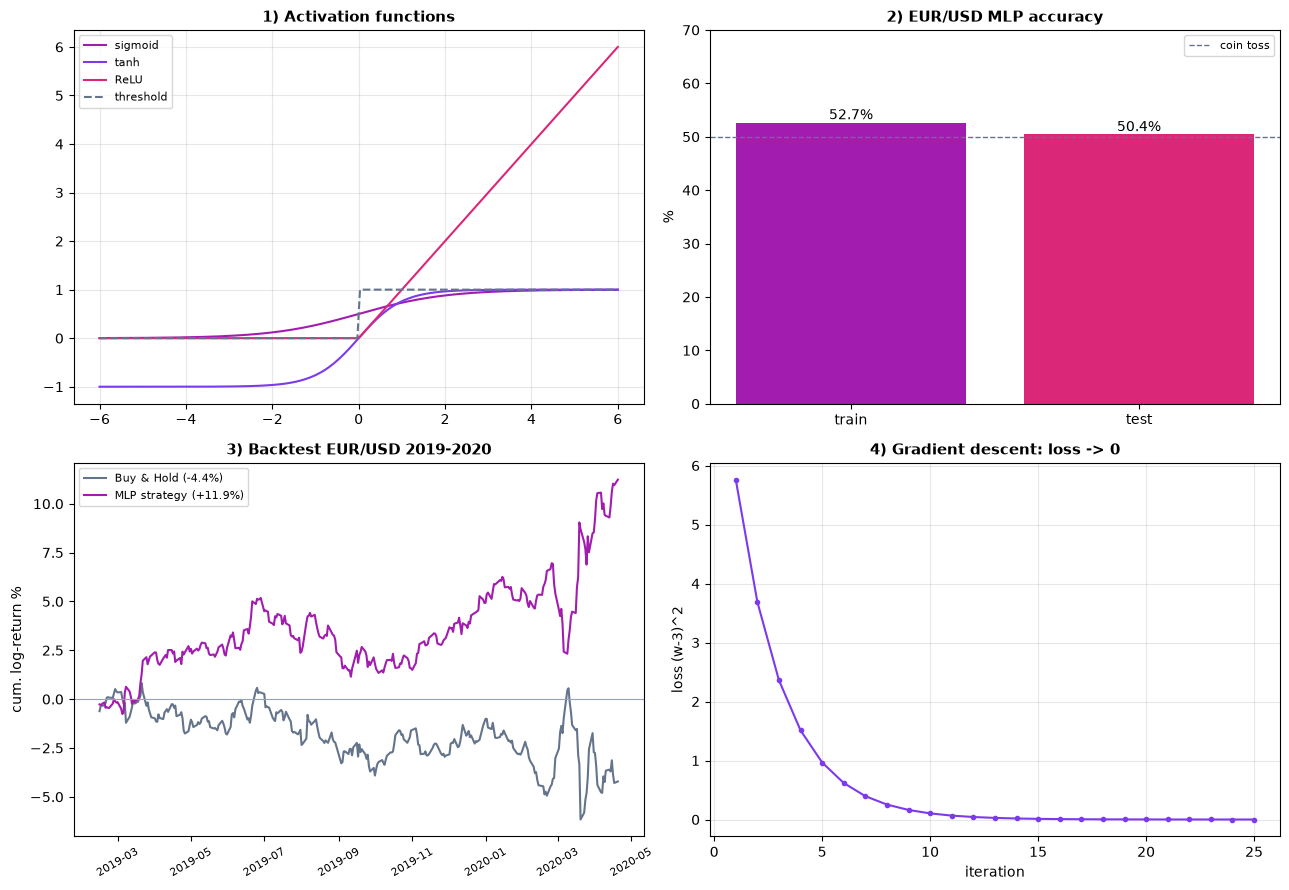

saved chart_1_mlt3.png


In [8]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
xx = np.linspace(-6, 6, 200)

# (1) activation functions
a = ax[0,0]
a.plot(xx, sigmoid(xx), label='sigmoid', color='#a21caf')
a.plot(xx, np.tanh(xx), label='tanh', color='#7c3aed')
a.plot(xx, relu(xx), label='ReLU', color='#db2777')
a.plot(xx, threshold(xx), label='threshold', color='#64748b', ls='--')
a.set_title('1) Activation functions', fontsize=11, weight='bold'); a.legend(fontsize=8); a.grid(alpha=.3)

# (2) MLP train vs test accuracy
a = ax[0,1]
bars = a.bar(['train','test'], [model.score(X_tr_s,y_tr)*100, model.score(X_te_s,y_te)*100],
             color=['#a21caf','#db2777'])
a.axhline(50, color='#64748b', ls='--', lw=1, label='coin toss')
a.bar_label(bars, fmt='%.1f%%'); a.set_ylim(0,70)
a.set_title('2) EUR/USD MLP accuracy', fontsize=11, weight='bold'); a.set_ylabel('%'); a.legend(fontsize=8)

# (3) backtest equity curve
a = ax[1,0]
a.plot(bt.index, bt['returns'].cumsum()*100, label=f'Buy & Hold ({(np.exp(bnh)-1)*100:+.1f}%)', color='#64748b')
a.plot(bt.index, bt['strategy_returns'].cumsum()*100, label=f'MLP strategy ({(np.exp(strat)-1)*100:+.1f}%)', color='#a21caf')
a.axhline(0, color='#94a3b8', lw=.8)
a.set_title('3) Backtest EUR/USD 2019-2020', fontsize=11, weight='bold'); a.set_ylabel('cum. log-return %')
a.legend(fontsize=8); a.tick_params(axis='x', labelrotation=30, labelsize=8)

# (4) gradient descent convergence
a = ax[1,1]
losses = [h[1] for h in hist]
a.plot(range(1, len(losses)+1), losses, marker='o', ms=3, color='#7c3aed')
a.set_title('4) Gradient descent: loss -> 0', fontsize=11, weight='bold')
a.set_xlabel('iteration'); a.set_ylabel('loss (w-3)^2'); a.grid(alpha=.3)

plt.tight_layout()
plt.savefig('chart_1_mlt3.png', dpi=110, bbox_inches='tight')
plt.show()
print('saved chart_1_mlt3.png')

## Recap
- A neuron is `a = Σ wᵢxᵢ + b` -> **activation**; stack them into layers to get an **MLP** (a universal approximator).
- **Activation functions**: sigmoid/tanh saturate (vanishing gradients, max sigmoid slope 0.25); **ReLU** does not.
- Real EUR/USD MLP: train **0.527** / test **0.504** — near coin-toss on close-to-close direction, yet the back-test **beats buy-and-hold (+11.9% vs -4.4%)**, proving P&L > accuracy for trading models.
- Learning = **gradient descent** (step down the loss gradient) + **backpropagation** (chain rule through layers).
- **Text mining**: strip stop-words, **TF-IDF**-vectorise, feed the numbers to a network for sentiment.